# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [235]:


# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import levene
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [236]:

# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')


**Vista previa e información general del conjunto de datos**

In [237]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [238]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


- El dataset contiene 40,000 registros y 9 columnas.
- No se identifican valores nulos, ya que todas las columnas cuentan con 40,000 valores no nulos.
- Las columnas categóricas (`user_id`, `landing`, `region`, `dispositivo`, `traffic_source` y `user_type`) tienen el tipo de dato object, lo cual es adecuado.
- La columna `converted` es de tipo `int64` y la columna `gasto` es de tipo `float64`, ambos apropiados para su contenido.
- La columna `date` está almacenada como `object`, por lo que se convertio al tipo `datetime` para facilitar el análisis de fechas.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [239]:
df["user_id"].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [240]:
# Resumen estadístico
df["date"] = pd.to_datetime(df["date"])
df["date"].describe()


count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [241]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [242]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [243]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [244]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df["landing"].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


- La columna `user_id` contiene 40,000 usuarios únicos, por lo que no se identifican registros duplicados.
- La columna `date` fue convertida al tipo `datetime` y el experimento abarca del 01 al 28 de enero de 2026, sin fechas fuera del rango esperado.
- La variable `gasto` es de tipo `float64` y no presenta valores inconsistentes. La mayoría de los usuarios no realizó compras, mientras que los usuarios que convirtieron registran gastos positivos.
- La variable `landing` contiene únicamente las categorías esperadas (A y B), con una distribución prácticamente equilibrada entre ambas versiones.
- En la revisión de las variables clave del experimento **no se identifican problemas de calidad de datos**, por lo que el dataset es adecuado para continuar con el análisis del experimento A/B.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [245]:

# Gasto por versión
gasto_A = df[(df['landing']=='A') & (df['converted']==1)]['gasto']
gasto_B = df[(df['landing']=='B') & (df['converted']==1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)


(2512, 3194)

In [246]:

print ('Promedio de gasto página A', gasto_A.mean())
print ('Promedio de gasto página B', gasto_B.mean())


Promedio de gasto página A 61.0865724522293
Promedio de gasto página B 68.74536005009392


### Prueba T 

**Hipótesis:**
- **Hipótesis nula (H₀):** No existen diferencias estadísticamente significativas en el gasto promedio de los usuarios que se convirtieron en clientes entre la página A y la página B.
- **Hipótesis alternativa (H₁):** Existen diferencias estadísticamente significativas en el gasto promedio de los usuarios que se convirtieron en clientes entre la página A y la página B.

In [247]:
#se realiza una prueba Levene para corroborar la homogeneidad de varianzas entre grupo A y B
l_stat, p_value_var = levene(gasto_A, gasto_B)

print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_value_var}")
print()
# Interpretar resultados
alpha = 0.05 
if p_value_var < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico de Levene: 29.17646453202917
Valor p: 6.875301988016449e-08

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [248]:
# Aplicar prueba t de Welch para grupos con varianzas no homogeneas 
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)
# Visualizar resultados
print(f"Estadístico :{t_stat}")
print(f"Valor p: {p_value}")
# Interpretar resultados
print()
alpha = 0.05   
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")


Estadístico :-9.48101092267275
Valor p: 3.627602231521493e-21

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**
- La prueba de Levene indicó que las varianzas entre los grupos A y B no son homogéneas, por lo que se utilizó la prueba t de Welch `(equal_var=False)`
- *Se rechaza la hipótesis nula (H₀)*, ya que el valor p  es menor que el nivel de significancia de 0.05. Por lo tanto, existe evidencia estadísticamente significativa para afirmar que el gasto promedio de los usuarios que se convirtieron en clientes difiere entre la página A y la página B.

**Interpretación de negocio:**  
- La página B presenta un gasto promedio mayor **(68.75)** que la página A **(61.09)** entre los usuarios que realizaron una conversión.
- Estos resultados indican que la `versión B genera un mayor valor económico por cliente convertido`, por lo que representa una mejor alternativa para el negocio en términos de ingresos promedio por usuario convertido.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalúa si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀):** No existen diferencias estadísticamente significativas en la tasa de conversión entre la página A y B.
- **Hipótesis alternativa (H₁):** Existen diferencias estadísticamente significativas en la tasa de conversión entre la página A y B


In [249]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [250]:
# Organizar datos en formato lista
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]

# Obtener tasa o porcentaje de éxito
tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

# Interpretar dirección de resultados
if tasa_A > tasa_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La página B tiene una mayor tasa de conversión (3.38%)


In [251]:

# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos , observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")
print()
# Interpretar resultados
alpha = 0.05   
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")


Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
- Se rechaza la hipótesis nula (H₀), ya que el valor p es menor que el nivel de significancia de 0.05. Por lo tanto, existe evidencia estadísticamente significativa de que la tasa de conversión difiere entre la página A y la página B.

**Interpretación de negocio:**  
- La página B presenta una tasa de conversión superior a la de la página A (15.96 % frente a 12.57 %).
- La diferencia observada es estadísticamente significativa, por lo que es muy poco probable que se deba al azar.
- Desde una perspectiva de negocio, la página B representa la mejor alternativa, al incrementar la probabilidad de conversión y generar un mayor número de clientes.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

In [252]:

# Construir tabla de contingencia 
tabla = pd.crosstab( df["traffic_source"], df["converted"])
print(tabla)


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [253]:

# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

# Interpretar resultados
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")
print()


Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.



In [254]:

# Tabla de contingencia normalizada
pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100


converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
- Se rechaza la hipótesis nula (H₀), ya que el valor p (0.034) es menor que el nivel de significancia de 0.05. Por lo tanto, existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

**Interpretación de negocio:**  
- Los resultados indican que la tasa de conversión varía ligeramente según el canal por el que llegan los usuarios.
- Organic registra el mayor número de conversiones (2,480), seguido de Ads (1,759), Email (918) y Referral (549). Sin embargo, estas cantidades también dependen del número de usuarios que provienen de cada fuente.
- Al analizar las tasas de conversión, Email presenta la mayor proporción de usuarios convertidos (14.99 %), seguido de Ads (14.74 %), mientras que Referral (13.88 %) y Organic (13.79 %) muestran tasas ligeramente menores.
- Aunque las diferencias entre las tasas de conversión son pequeñas, la prueba estadística indica que son estadísticamente significativas. Esto sugiere que la fuente de tráfico es un factor que debe considerarse al evaluar el desempeño de las campañas de adquisición de usuarios.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.

In [255]:
# Construir tabla de contingencia 
tabla = pd.crosstab( df["user_type"], df["converted"])
print(tabla)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [256]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

# Interpretar resultados
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")
print()

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.



In [257]:
# Tabla de contingencia normalizada
pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


### 📝 Conclusión e interpretación

**Decisión:**  
- No se rechaza la hipótesis nula (H₀), ya que el valor p (0.474) es mayor que el nivel de significancia de 0.05. Por lo tanto, no existe evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión.

**Interpretación de negocio:**  
- Los usuarios nuevos presentan una tasa de conversión de 14.36 %, mientras que los usuarios recurrentes tienen una tasa de 14.09 %.
- La diferencia entre ambas tasas es muy pequeña y la prueba chi-cuadrado indica que no es estadísticamente significativa.
- Desde una perspectiva de negocio, el tipo de usuario no parece ser un factor determinante para la conversión, por lo que las estrategias para incrementar las conversiones deberían enfocarse en otras variables que sí mostraron una relación significativa.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

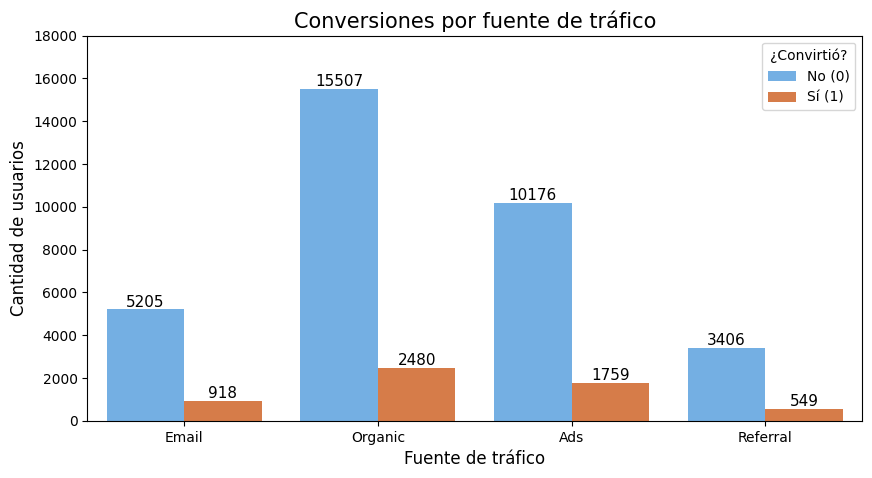

In [258]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#62b0f5", "#ed7632"] )

# Agregar valores
for bar in ax.patches:        
    height = bar.get_height()
    ax.text(x=bar.get_x()+bar.get_width() /2, 
            y=height,                         
            s=height,                        
            ha='center',                      
            va='bottom',                      
            fontsize=11)                             

# Añadir detalles
plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,18000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

- En la gráfica se puede observar que a fuente Organic registra el mayor número de conversiones, mientras que en todas las fuentes predominan los usuarios que no convierten. El gráfico muestra diferencias en el volumen de conversiones entre los canales de tráfico.

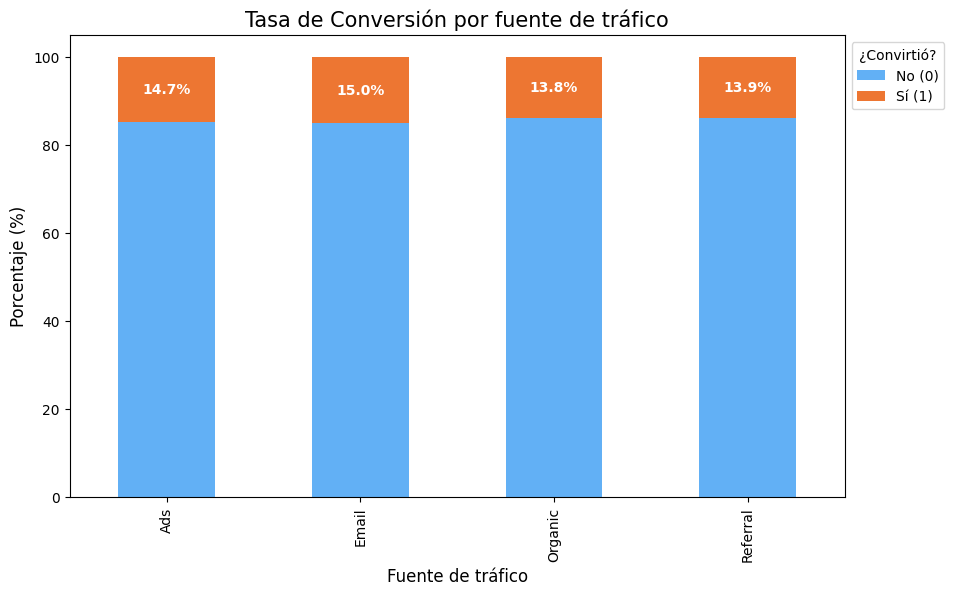

In [259]:
# Tabla de contingencia normalizada
tabla = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

# Gráfica de barras apiladas
ax = tabla.plot(kind='bar',
                stacked=True,
                figsize=(10, 6),
                color=["#62b0f5", "#ed7632"])

# Agregar solo el porcentaje de conversión
for i, valor in enumerate(tabla[1]):
    ax.text(
        x=i,
        y=100 - valor/2,
        s=f"{valor:.1f}%",
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )
    
# Añadir detalles
plt.title('Tasa de Conversión por fuente de tráfico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'],
           loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

- Las tasas de conversión son similares entre las distintas fuentes de tráfico. Email y Ads presentan una proporción ligeramente mayor de usuarios convertidos, mientras que Organic y Referral muestran tasas ligeramente menores.

### Relación entre el tipo de usuario y la conversión

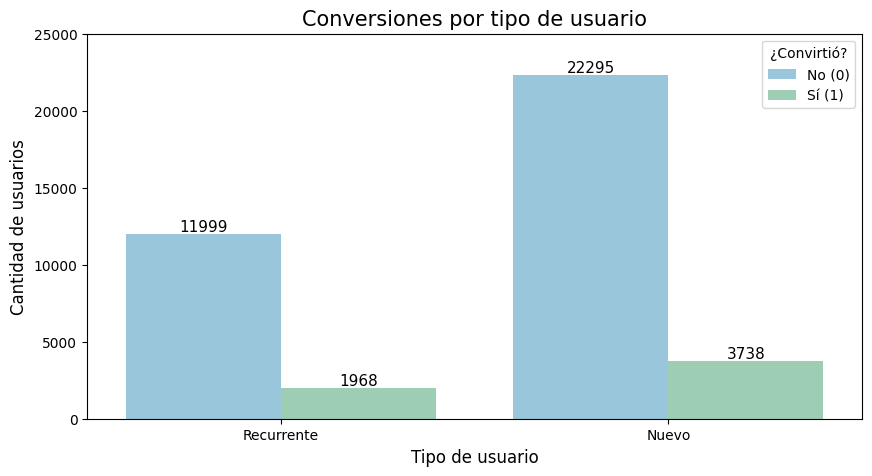

In [260]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='user_type', hue='converted', palette = ["#8ecae6", "#95d5b2"] )

# Agregar valores
for bar in ax.patches:        
    height = bar.get_height()
    ax.text(x=bar.get_x()+bar.get_width() /2, 
            y=height,                         
            s=height,                        
            ha='center',                      
            va='bottom',                      
            fontsize=11)                             

# Añadir detalles
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,25000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

- Los usuarios nuevos registran un mayor número de conversiones que los usuarios recurrentes; sin embargo, esto se debe principalmente a que hay más usuarios nuevos en el dataset. La proporción de conversión es muy similar entre ambos grupos, lo que coincide con la prueba chi-cuadrado, que no encontró una asociación significativa entre el tipo de usuario y la conversión.

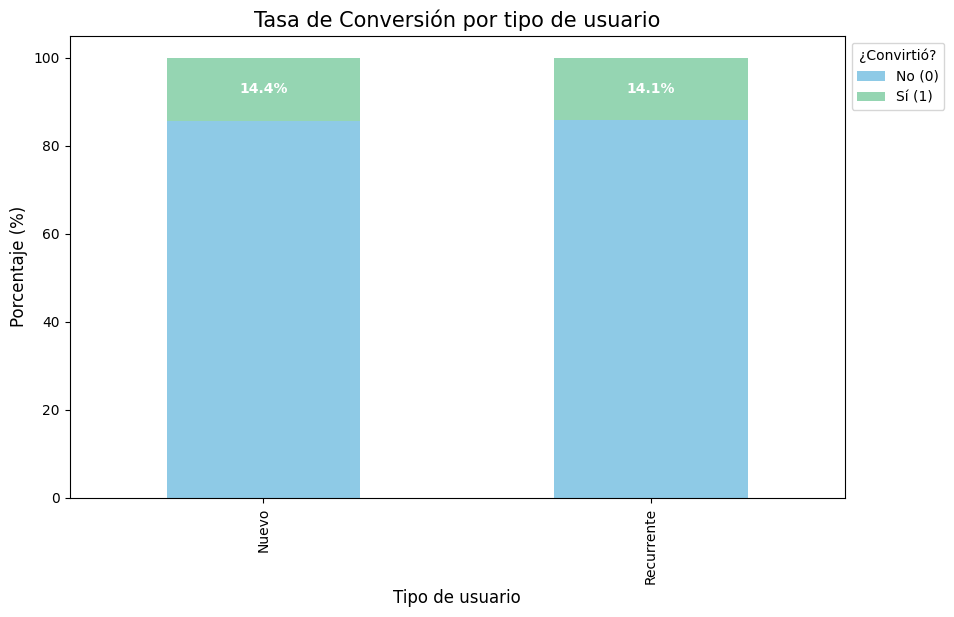

In [261]:
# Tabla de contingencia normalizada
tabla = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

# Gráfica de barras apiladas
ax = tabla.plot(kind='bar',
                stacked=True,
                figsize=(10, 6),
                color=["#8ecae6", "#95d5b2"])

# Agregar solo el porcentaje de conversión
for i, valor in enumerate(tabla[1]):
    ax.text(
        x=i,
        y=100 - valor/2,
        s=f"{valor:.1f}%",
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )
    
# Añadir detalles
plt.title('Tasa de Conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'],
           loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

- La tasa de conversión es muy similar entre los usuarios nuevos (14.4 %) y los recurrentes (14.1 %). Esto confirma que el tipo de usuario no influye de manera significativa en la probabilidad de conversión.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observación 1: La página B registró un gasto promedio de 68.75, superior al de la página A (61.09).
- Observación 2: La diferencia en el gasto promedio fue estadísticamente significativa (prueba t de Welch, p < 0.05).
- **Interpretación:** La versión B genera un mayor ingreso promedio por cliente convertido, por lo que representa una mejor alternativa para maximizar el valor económico de las conversiones

<br>

**Tasa de conversión:** 
- Observación 1: La página B obtuvo una tasa de conversión de 15.96 %, mientras que la página A alcanzó 12.57 %.
- Observación 2: La diferencia en la tasa de conversión fue estadísticamente significativa (prueba Z, p < 0.05).
- **Interpretación:** La página B convierte una mayor proporción de visitantes en clientes, por lo que presenta un mejor desempeño que la versión A.

---

#### 📊 **Segmentación por fuente de tráfico**
- Observación: La fuente Organic generó el mayor número de conversiones debido a su mayor volumen de usuarios; sin embargo, Email presentó la mayor tasa de conversión, seguida de Ads. La prueba chi-cuadrado mostró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.
- **Interpretación:** La efectividad para convertir usuarios varía según el canal de adquisición, por lo que la fuente de tráfico debe considerarse al diseñar estrategias de marketing.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observación: Los usuarios nuevos y recurrentes presentan tasas de conversión muy similares (14.36 % y 14.09 %, respectivamente), y la prueba chi-cuadrado no encontró una asociación significativa entre el tipo de usuario y la conversión.
- **Interpretación:** El tipo de usuario no influye de manera significativa en la probabilidad de conversión dentro de este experimento.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Implementar la versión B como página principal, ya que genera una mayor tasa de conversión y un mayor gasto promedio por cliente convertido.
- Fortalecer las campañas en los canales Email y Ads, ya que presentan las mayores tasas de conversión, sin dejar de aprovechar el alto volumen de usuarios proveniente de Organic.
- Priorizar la optimización de la página y de los canales de adquisición antes que segmentar estrategias por tipo de usuario, ya que este último no mostró un efecto significativo sobre la conversión.